In [ ]:
 !pip install -q datasets transformers seqeval torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

os.makedirs("figures", exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [ ]:
import urllib.request
import os

os.makedirs("conll2003", exist_ok=True)

# CoNLL-2003 dosyalarını direkt indir
base = "https://raw.githubusercontent.com/synalp/NER/master/corpus/CoNLL-2003/"
files = {"train": "eng.train", "validation": "eng.testa", "test": "eng.testb"}

for split, fname in files.items():
    url = base + fname
    dest = f"conll2003/{split}.txt"
    urllib.request.urlretrieve(url, dest)
    print(f"İndirildi: {dest}")

# Dosyaları parse et
def parse_conll(filepath):
    sentences, tokens, tags = [], [], []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith("-DOCSTART-") or line == "":
                if tokens:
                    sentences.append({"tokens": tokens, "ner_tags": tags})
                    tokens, tags = [], []
            else:
                parts = line.split()
                tokens.append(parts[0])
                tags.append(parts[3])  # IOB2 etiketi
    return sentences

raw = {
    "train":      parse_conll("conll2003/train.txt"),
    "validation": parse_conll("conll2003/validation.txt"),
    "test":       parse_conll("conll2003/test.txt"),
}

# Etiket listesi
all_tags = set()
for split in raw.values():
    for ex in split:
        all_tags.update(ex["ner_tags"])

LABEL_LIST = sorted(all_tags)
# O'yu başa al
if "O" in LABEL_LIST:
    LABEL_LIST.remove("O")
    LABEL_LIST = ["O"] + LABEL_LIST

tag2idx = {tag: i for i, tag in enumerate(LABEL_LIST)}
idx2tag = {i: tag for tag, i in tag2idx.items()}

# String etiketleri int'e çevir
for split in raw.values():
    for ex in split:
        ex["ner_tags"] = [tag2idx[t] for t in ex["ner_tags"]]

print(f"Etiket listesi: {LABEL_LIST}")
print(f"Toplam etiket: {len(LABEL_LIST)}")
for split, data in raw.items():
    tokens = sum(len(x["tokens"]) for x in data)
    print(f"{split:12s}: {len(data):5d} cümle | {tokens:7d} token")

sample = raw["train"][0]
print("\nÖrnek cümle:")
for token, tag_id in zip(sample["tokens"], sample["ner_tags"]):
    print(f"  {token:15s} {LABEL_LIST[tag_id]}")

İndirildi: conll2003/train.txt
İndirildi: conll2003/validation.txt
İndirildi: conll2003/test.txt
Etiket listesi: ['O', 'B-LOC', 'B-MISC', 'B-ORG', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER']
Toplam etiket: 8
train       : 14041 cümle |  203621 token
validation  :  3250 cümle |   51362 token
test        :  3453 cümle |   46435 token

Örnek cümle:
  EU              I-ORG
  rejects         O
  German          I-MISC
  call            O
  to              O
  boycott         O
  British         I-MISC
  lamb            O
  .               O


In [ ]:
def compute_metrics(true_labels, pred_labels, model_name="Model"):
    """seqeval ile Precision, Recall, F1 hesapla."""
    # seqeval string etiket listesi bekler
    report = classification_report(true_labels, pred_labels, digits=4)
    p = precision_score(true_labels, pred_labels)
    r = recall_score(true_labels, pred_labels)
    f = f1_score(true_labels, pred_labels)
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"  Precision: {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
    print(f"{'='*55}")
    print(report)
    return p, r, f


def show_ner_errors(sentences, true_tags, pred_tags, n=5, model_name="Model"):
    """Yanlış etiketlenen örnekleri göster."""
    print(f"\n{'='*60}")
    print(f"  {model_name} — Hatalı Tahminler")
    print(f"{'='*60}")
    count = 0
    for sent, true, pred in zip(sentences, true_tags, pred_tags):
        if true != pred and count < n:
            errors = [(t, tr, pr) for t, tr, pr in zip(sent, true, pred) if tr != pr]
            if errors:
                print(f"\n  Cümle: {' '.join(sent[:15])}...")
                print(f"  {'Token':<15} {'True':>8} {'Pred':>8}")
                print(f"  {'-'*35}")
                for tok, tr, pr in errors[:5]:
                    print(f"  {tok:<15} {tr:>8} {pr:>8}")
                count += 1



████████████████████████████████████████████████████████████
  MODEL 1: BiLSTM-CRF
████████████████████████████████████████████████████████████
Vocab boyutu : 20002
Etiket sayısı: 8 → ['O', 'B-LOC', 'B-MISC', 'B-ORG', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER']
BiLSTM-CRF parametreleri: 2,086,304

BiLSTM-CRF eğitimi başlıyor...
Epoch 1/10 | Loss: 8.9964
Epoch 2/10 | Loss: 4.9459
Epoch 4/10 | Loss: 3.0041
Epoch 6/10 | Loss: 2.1721
Epoch 8/10 | Loss: 1.6592
Epoch 10/10 | Loss: 1.3317

  BiLSTM-CRF (TEST)
  Precision: 0.0851 | Recall: 0.0627 | F1: 0.0722
              precision    recall  f1-score   support

         LOC     0.1248    0.1145    0.1194      1668
        MISC     0.0773    0.0627    0.0692       702
         ORG     0.1062    0.0566    0.0738      1661
         PER     0.0212    0.0155    0.0179      1617

   micro avg     0.0851    0.0627    0.0722      5648
   macro avg     0.0824    0.0623    0.0701      5648
weighted avg     0.0838    0.0627    0.0707      5648


  BiLSTM-CRF

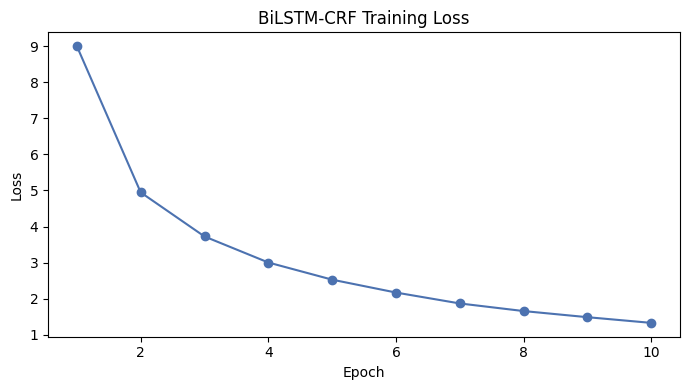

In [ ]:
# MODEL 1: BiLSTM-CRF

print("\n" + "█"*60)
print("  MODEL 1: BiLSTM-CRF")
print("█"*60)

# ── Hyperparameters ───────────────────────────────────────────────────────────
EMBED_DIM   = 100
HIDDEN_DIM  = 128
DROPOUT     = 0.3
BATCH_SIZE  = 32
EPOCHS_CRF  = 10
LR_CRF      = 1e-3
MAX_LEN_CRF = 128

# ── Vocabulary ───────────────────────────────────────────────────────────────
from collections import Counter

word_counter = Counter()
for ex in raw["train"]:
    word_counter.update([t.lower() for t in ex["tokens"]])

word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, c in word_counter.most_common(20000):
    word2idx[w] = len(word2idx)

tag2idx = {tag: i for i, tag in enumerate(LABEL_LIST)}
idx2tag = {i: tag for tag, i in tag2idx.items()}

print(f"Vocab boyutu : {len(word2idx)}")
print(f"Etiket sayısı: {len(tag2idx)} → {list(tag2idx.keys())}")


# ── Dataset ──────────────────────────────────────────────────────────────────
class NERDataset(Dataset):
    def __init__(self, data, word2idx, tag2idx, max_len):
        self.samples = []
        for ex in data:
            tokens = [word2idx.get(t.lower(), 1) for t in ex["tokens"]][:max_len]
            tags   = ex["ner_tags"][:max_len]
            # padding
            pad_len = max_len - len(tokens)
            tokens += [0] * pad_len
            tags   += [tag2idx["O"]] * pad_len
            mask = [1] * min(len(ex["tokens"]), max_len) + [0] * pad_len
            self.samples.append((
                torch.tensor(tokens, dtype=torch.long),
                torch.tensor(tags,   dtype=torch.long),
                torch.tensor(mask,   dtype=torch.bool)
            ))

    def __len__(self):  return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


train_ds_crf = NERDataset(raw["train"],      word2idx, tag2idx, MAX_LEN_CRF)
val_ds_crf   = NERDataset(raw["validation"], word2idx, tag2idx, MAX_LEN_CRF)
test_ds_crf  = NERDataset(raw["test"],       word2idx, tag2idx, MAX_LEN_CRF)

train_loader_crf = DataLoader(train_ds_crf, batch_size=BATCH_SIZE, shuffle=True)
val_loader_crf   = DataLoader(val_ds_crf,   batch_size=BATCH_SIZE)
test_loader_crf  = DataLoader(test_ds_crf,  batch_size=BATCH_SIZE)


# ── CRF Layer ────────────────────────────────────────────────────────────────
class CRF(nn.Module):
    """Basit CRF katmanı — Viterbi decode ile."""
    def __init__(self, num_tags):
        super().__init__()
        self.num_tags = num_tags
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))
        self.start_transitions = nn.Parameter(torch.randn(num_tags))
        self.end_transitions   = nn.Parameter(torch.randn(num_tags))

    def forward(self, emissions, tags, mask):
        """Negatif log-likelihood döndür."""
        score = self._compute_score(emissions, tags, mask)
        norm = self._compute_normalizer(emissions, mask)
        # Her dizi için normalizer'dan skoru çıkarıp tüm batch'in ortalamasını alıyoruz:
        return (norm - score).mean()

    def decode(self, emissions, mask):
        """Viterbi ile en iyi tag dizisini bul."""
        batch_size, seq_len, num_tags = emissions.shape
        viterbi = emissions[:, 0] + self.start_transitions
        backpointers = []

        for i in range(1, seq_len):
            emit = emissions[:, i].unsqueeze(2)
            trans = self.transitions.unsqueeze(0)
            score = viterbi.unsqueeze(2) + trans + emit
            best_score, best_tag = score.max(1)
            backpointers.append(best_tag)

            active = mask[:, i].unsqueeze(1).expand_as(best_score)
            viterbi = torch.where(active, best_score, viterbi)

        viterbi += self.end_transitions
        best_tags_list = []
        _, best_last_tag = viterbi.max(1)
        best_tags = [best_last_tag.unsqueeze(1)]

        for bp in reversed(backpointers):
            best_last_tag = bp.gather(1, best_tags[-1])
            best_tags.append(best_last_tag)

        best_tags.reverse()
        best_tags = torch.cat(best_tags, dim=1)
        return best_tags

    def _compute_score(self, emissions, tags, mask):
        batch_size, seq_len, _ = emissions.shape
        score = self.start_transitions[tags[:, 0]]
        score += emissions[:, 0].gather(1, tags[:, 0].unsqueeze(1)).squeeze(1)

        for i in range(1, seq_len):
            active = mask[:, i]
            trans_score = self.transitions[tags[:, i-1], tags[:, i]]
            emit_score  = emissions[:, i].gather(1, tags[:, i].unsqueeze(1)).squeeze(1)
            score += torch.where(active, trans_score + emit_score,
                                 torch.zeros_like(score))

        last_tag_idx = mask.long().sum(1) - 1
        last_tags = tags.gather(1, last_tag_idx.unsqueeze(1)).squeeze(1)
        score += self.end_transitions[last_tags]
        return score

    def _compute_normalizer(self, emissions, mask):
        batch_size, seq_len, num_tags = emissions.shape
        score = self.start_transitions + emissions[:, 0]

        for i in range(1, seq_len):
            broadcast_score = score.unsqueeze(2)
            broadcast_emit  = emissions[:, i].unsqueeze(1)
            next_score = broadcast_score + self.transitions + broadcast_emit
            next_score = torch.logsumexp(next_score, dim=1)
            score = torch.where(mask[:, i].unsqueeze(1).expand_as(next_score),
                                next_score, score)

        score += self.end_transitions
        # SONDAN .mean() KISMINI SİLDİK
        return torch.logsumexp(score, dim=1)


# ── BiLSTM-CRF Model ─────────────────────────────────────────────────────────
class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_tags, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_dim // 2, num_layers=1,
                            bidirectional=True, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, num_tags)
        self.crf = CRF(num_tags)

    def forward(self, x, tags, mask):
        emb = self.dropout(self.embedding(x))
        out, _ = self.lstm(emb)
        emissions = self.fc(self.dropout(out))
        loss = self.crf(emissions, tags, mask)
        return loss

    def predict(self, x, mask):
        emb = self.dropout(self.embedding(x))
        out, _ = self.lstm(emb)
        emissions = self.fc(out)
        return self.crf.decode(emissions, mask)


model_crf = BiLSTM_CRF(len(word2idx), EMBED_DIM, HIDDEN_DIM,
                         len(tag2idx), DROPOUT).to(DEVICE)
optimizer_crf = torch.optim.Adam(model_crf.parameters(), lr=LR_CRF)
print(f"BiLSTM-CRF parametreleri: {sum(p.numel() for p in model_crf.parameters()):,}")


# ── Eğitim ───────────────────────────────────────────────────────────────────
def crf_train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for tokens, tags, mask in loader:
        tokens, tags, mask = tokens.to(DEVICE), tags.to(DEVICE), mask.to(DEVICE)
        optimizer.zero_grad()
        loss = model(tokens, tags, mask)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def crf_predict(model, loader, idx2tag, label_list):
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for tokens, tags, mask in loader:
            tokens, mask = tokens.to(DEVICE), mask.to(DEVICE)
            preds = model.predict(tokens, mask)
            for i in range(len(tokens)):
                length = mask[i].sum().item()
                pred_tags = [idx2tag[p.item()] for p in preds[i][:length]]
                true_tags = [idx2tag[t.item()] for t in tags[i][:length]]
                all_preds.append(pred_tags)
                all_trues.append(true_tags)
    return all_trues, all_preds


print("\nBiLSTM-CRF eğitimi başlıyor...")
history_crf = []
for epoch in range(1, EPOCHS_CRF + 1):
    loss = crf_train_epoch(model_crf, train_loader_crf, optimizer_crf)
    history_crf.append(loss)
    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{EPOCHS_CRF} | Loss: {loss:.4f}")

# Test
true_crf, pred_crf = crf_predict(model_crf, test_loader_crf, idx2tag, LABEL_LIST)
p_crf, r_crf, f_crf = compute_metrics(true_crf, pred_crf, "BiLSTM-CRF (TEST)")

# Hata analizi için token listesi
test_sentences = [ex["tokens"] for ex in raw["test"]]
show_ner_errors(test_sentences, true_crf, pred_crf, n=5, model_name="BiLSTM-CRF")

# Loss eğrisi
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS_CRF+1), history_crf, marker="o", color="#4C72B0")
plt.title("BiLSTM-CRF Training Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout()
plt.savefig("figures/q2_crf_loss.png", dpi=150)
plt.show()


In [ ]:
# MODEL 2: BERT Token Classification

from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                           get_linear_schedule_with_warmup)

print("\n" + "█"*60)
print("  MODEL 2: BERT Token Classification")
print("█"*60)

BERT_MODEL    = "distilbert-base-uncased"
MAX_LEN_BERT  = 128
BATCH_BERT    = 16
EPOCHS_BERT   = 3
LR_BERT       = 5e-5

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

# id2label / label2id
id2label = {i: l for i, l in enumerate(LABEL_LIST)}
label2id = {l: i for i, l in enumerate(LABEL_LIST)}


# ── Dataset — Token alignment ─────────────────────────────────────────────────
# BERT subword tokenizer bir kelimeyi birden fazla token'a bölebilir.
# Sadece her kelimenin İLK subtoken'ına etiket atıyoruz, gerisine -100 (ignore).

class BertNERDataset(Dataset):
    def __init__(self, data, tokenizer, label2id, max_len):
        self.samples = []
        for ex in data:
            tokens    = ex["tokens"]
            ner_tags  = ex["ner_tags"]
            encoding  = tokenizer(
                tokens,
                is_split_into_words=True,
                truncation=True,
                padding="max_length",
                max_length=max_len,
                return_tensors="pt"
            )
            word_ids = encoding.word_ids(batch_index=0)
            labels = []
            prev_word_id = None
            for word_id in word_ids:
                if word_id is None:
                    labels.append(-100)          # [CLS], [SEP], [PAD]
                elif word_id != prev_word_id:
                    labels.append(ner_tags[word_id])   # ilk subtoken
                else:
                    labels.append(-100)          # devam subtoken'ları yoksay
                prev_word_id = word_id

            self.samples.append({
                "input_ids":      encoding["input_ids"].squeeze(),
                "attention_mask": encoding["attention_mask"].squeeze(),
                "labels":         torch.tensor(labels, dtype=torch.long)
            })

    def __len__(self):  return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


print("BERT tokenization yapılıyor...")
bert_train_ds = BertNERDataset(raw["train"],      bert_tokenizer, label2id, MAX_LEN_BERT)
bert_val_ds   = BertNERDataset(raw["validation"], bert_tokenizer, label2id, MAX_LEN_BERT)
bert_test_ds  = BertNERDataset(raw["test"],       bert_tokenizer, label2id, MAX_LEN_BERT)

bert_train_loader = DataLoader(bert_train_ds, batch_size=BATCH_BERT, shuffle=True)
bert_val_loader   = DataLoader(bert_val_ds,   batch_size=BATCH_BERT)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=BATCH_BERT)

# ── Model ────────────────────────────────────────────────────────────────────
bert_ner = AutoModelForTokenClassification.from_pretrained(
    BERT_MODEL,
    num_labels=len(LABEL_LIST),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(DEVICE)

optimizer_bert = torch.optim.AdamW(bert_ner.parameters(), lr=LR_BERT, weight_decay=0.01)
total_steps = len(bert_train_loader) * EPOCHS_BERT
scheduler = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)
print(f"BERT-NER parametreleri: {sum(p.numel() for p in bert_ner.parameters()):,}")


# ── Eğitim ───────────────────────────────────────────────────────────────────
def bert_ner_train(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        optimizer.zero_grad()
        out  = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = out.loss
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def bert_ner_predict(model, loader, id2label):
    """Tahmin et, -100 etiketlerini ve padding'i atla."""
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["labels"]
            out = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = out.logits.argmax(-1).cpu()

            for i in range(len(labels)):
                true_seq, pred_seq = [], []
                for true_id, pred_id in zip(labels[i], preds[i]):
                    if true_id == -100:
                        continue
                    true_seq.append(id2label[true_id.item()])
                    pred_seq.append(id2label[pred_id.item()])
                all_trues.append(true_seq)
                all_preds.append(pred_seq)
    return all_trues, all_preds


print("\nBERT-NER eğitimi başlıyor...")
for epoch in range(1, EPOCHS_BERT + 1):
    loss = bert_ner_train(bert_ner, bert_train_loader, optimizer_bert, scheduler)
    print(f"Epoch {epoch}/{EPOCHS_BERT} | Loss: {loss:.4f}")

# Test
true_bert, pred_bert = bert_ner_predict(bert_ner, bert_test_loader, id2label)
p_bert, r_bert, f_bert = compute_metrics(true_bert, pred_bert, "BERT-NER (TEST)")
show_ner_errors(test_sentences, true_bert, pred_bert, n=5, model_name="BERT-NER")

# Drive'a kaydet
# from google.colab import drive
# drive.mount('/content/drive')
# bert_ner.save_pretrained("/content/drive/MyDrive/CENG467/q2_bert_ner")



████████████████████████████████████████████████████████████
  MODEL 2: BERT Token Classification
████████████████████████████████████████████████████████████


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERT tokenization yapılıyor...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT-NER parametreleri: 66,369,032

BERT-NER eğitimi başlıyor...
Epoch 1/3 | Loss: 0.1858
Epoch 2/3 | Loss: 0.0273
Epoch 3/3 | Loss: 0.0118

  BERT-NER (TEST)
  Precision: 0.8958 | Recall: 0.9074 | F1: 0.9015
              precision    recall  f1-score   support

         LOC     0.9047    0.9286    0.9165      1667
        MISC     0.7590    0.8077    0.7826       702
         ORG     0.8810    0.8736    0.8773      1661
         PER     0.9647    0.9635    0.9641      1616

   micro avg     0.8958    0.9074    0.9015      5646
   macro avg     0.8774    0.8933    0.8851      5646
weighted avg     0.8968    0.9074    0.9019      5646


  BERT-NER — Hatalı Tahminler

  Cümle: SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT ....
  Token               True     Pred
  -----------------------------------
  CHINA              I-PER    I-LOC

  Cümle: Cuttitta announced his retirement after the 1995 World Cup , where he took issue with...
  Token               True     Pred
  -------


════════════════════════════════════════════════════════════
  GENEL SONUÇLAR (Test Seti)
════════════════════════════════════════════════════════════
  Model                 Precision     Recall         F1
------------------------------------------------------------
  BiLSTM-CRF           0.0851     0.0627     0.0722
  BERT-NER             0.8958     0.9074     0.9015
════════════════════════════════════════════════════════════


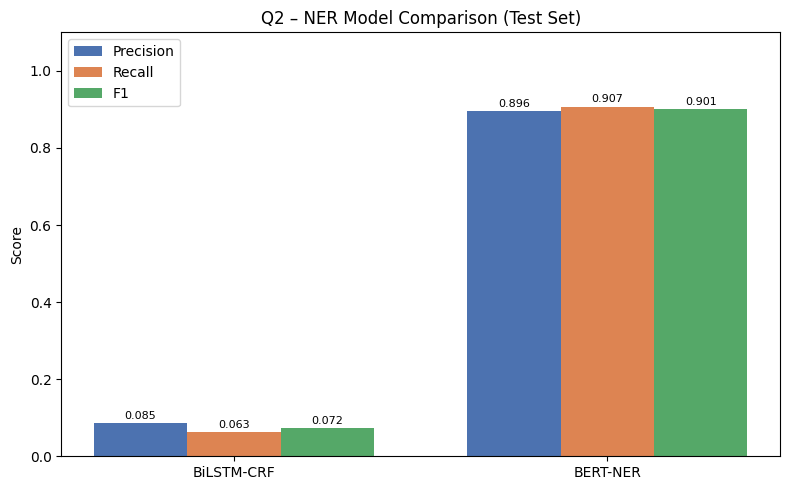


✅ Q2 tamamlandı! Rapor grafiklerin 'figures' klasörüne kaydedildi.


In [ ]:
print("\n" + "═"*60)
print("  GENEL SONUÇLAR (Test Seti)")
print("═"*60)
print(f"  {'Model':<20} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*60)
print(f"  {'BiLSTM-CRF':<20} {p_crf:.4f}     {r_crf:.4f}     {f_crf:.4f}")
print(f"  {'BERT-NER':<20} {p_bert:.4f}     {r_bert:.4f}     {f_bert:.4f}")
print("═"*60)

# Bar chart
models   = ["BiLSTM-CRF", "BERT-NER"]
prec     = [p_crf, p_bert]
rec      = [r_crf, r_bert]
f1s      = [f_crf, f_bert]

x = np.arange(len(models))
w = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w,   prec, w, label="Precision", color="#4C72B0")
b2 = ax.bar(x,       rec,  w, label="Recall",    color="#DD8452")
b3 = ax.bar(x + w,   f1s,  w, label="F1",        color="#55A868")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Q2 – NER Model Comparison (Test Set)")
ax.legend()
for bar in b1.patches + b2.patches + b3.patches:
    ax.annotate(f"{bar.get_height():.3f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("figures/q2_comparison.png", dpi=150)
plt.show()

print("\n✅ Q2 tamamlandı! Sonuçları main.tex'e gir.")
